# BLS signal: polarization optics

This example shows how to describe the polarization of the laser beam and of the detection with the `bls.polarization` submodule of SpinWaveToolkit (SWT), which uses the Jones calculus, and how to use it in the calculation of the BLS signal of a single magnetic layer.

The Jones vectors (`(Ex, Ey)`, shape `(2,)`) or spatially varying Jones fields (shape `(2, Nkx, Nky)`) describe the beam in the entrance pupil of the objective lens and can be passed as `pol_type` to `ObjectiveLens.getPupilField()`.  The same polarization types can be used for the output analyzer of the Green function BLS signal functions.

Related examples: [GF#2](BLS_signal_from_GF_pupil.ipynb) (Green functions, pupil fields), [RT#2](BLS_signal_from_RT_pupil.ipynb) (reciprocity theorem, pupil fields).

In [7]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import SpinWaveToolkit as SWT

pol = SWT.bls.polarization
warnings.filterwarnings("ignore", message=".*experimental function.*")

### 1. Jones vectors and optical elements

`jones_vector()` gives the basic polarization states (angles in degrees from the *x* axis), and the optical elements return Jones matrices, which are applied with `apply_jones_matrix()`.  For example, a quarter-wave plate at 45° turns the *x*-polarized beam into a right-hand circularly polarized one (up to a global phase), a half-wave plate at 22.5° rotates the polarization by 45°, and a linear polarizer follows Malus's law.

In [8]:
x_pol = pol.jones_vector("linear", angle=0)
print("linear 30°:         ", np.round(pol.jones_vector("linear", angle=30), 3))
print("rcp:                ", np.round(pol.jones_vector("rcp"), 3))
print("lcp:                ", np.round(pol.jones_vector("lcp"), 3))
print("elliptical 0°, 0.5: ", np.round(pol.jones_vector("elliptical", angle=0,
                                                        axis_ratio=0.5), 3))

# optical elements acting on the x-polarized beam
e_qwp = pol.apply_jones_matrix(pol.quarter_wave_plate(45), x_pol)
e_hwp = pol.apply_jones_matrix(pol.half_wave_plate(22.5), x_pol)
print("QWP at 45° on x:    ", np.round(e_qwp, 3),
      "= rcp up to a phase:",
      np.isclose(abs(np.vdot(pol.jones_vector("rcp"), e_qwp)), 1))
print("HWP at 22.5° on x:  ", np.round(e_hwp, 3))
for angle in (0, 30, 60, 90):
    e = pol.apply_jones_matrix(pol.linear_polarizer(angle), x_pol)
    print(f"polarizer at {angle:2d}°:"
          f" transmitted intensity {np.sum(np.abs(e)**2):.3f}"
          f" (cos² = {np.cos(np.deg2rad(angle))**2:.3f})")

linear 30°:          [0.866+0.j 0.5  +0.j]
rcp:                 [ 0.707+0.j    -0.   -0.707j]
lcp:                 [0.707+0.j    0.   +0.707j]
elliptical 0°, 0.5:  [0.894+0.j    0.   +0.447j]
QWP at 45° on x:     [0.5+0.5j 0.5-0.5j] = rcp up to a phase: True
HWP at 22.5° on x:   [0.707+0.j 0.707-0.j]
polarizer at  0°: transmitted intensity 1.000 (cos² = 1.000)
polarizer at 30°: transmitted intensity 0.750 (cos² = 0.750)
polarizer at 60°: transmitted intensity 0.250 (cos² = 0.250)
polarizer at 90°: transmitted intensity 0.000 (cos² = 0.000)


### 2. Spatially varying elements and focused beams

The radial and azimuthal polarizations, the spiral phase plate and the q-plate depend on the azimuth of the transverse coordinates.  In the entrance pupil, the azimuth is the same in real space and in reciprocal space, so these elements are evaluated directly on the k-space grid of the pupil field.  A q-plate (q = 1/2) turns the *x*-polarized beam into a radially polarized one (and a *y*-polarized beam into an azimuthally polarized one, up to a global phase), and a spiral phase plate imprints the phase `exp(i*l*phi)` of a vortex beam with orbital angular momentum `l`.

Below, the pupil fields of several beams and their intensities in the focal plane are shown.  The focal field follows from the pupil field (angular spectrum) as `E(r) = ∫ E_k(k) exp(i k·r) d²k`, which is evaluated here directly on a small real-space grid.  The radially polarized beam has a strong longitudinal component `Ez` on the optical axis, while the vortex beam has a doughnut-shaped transverse intensity.

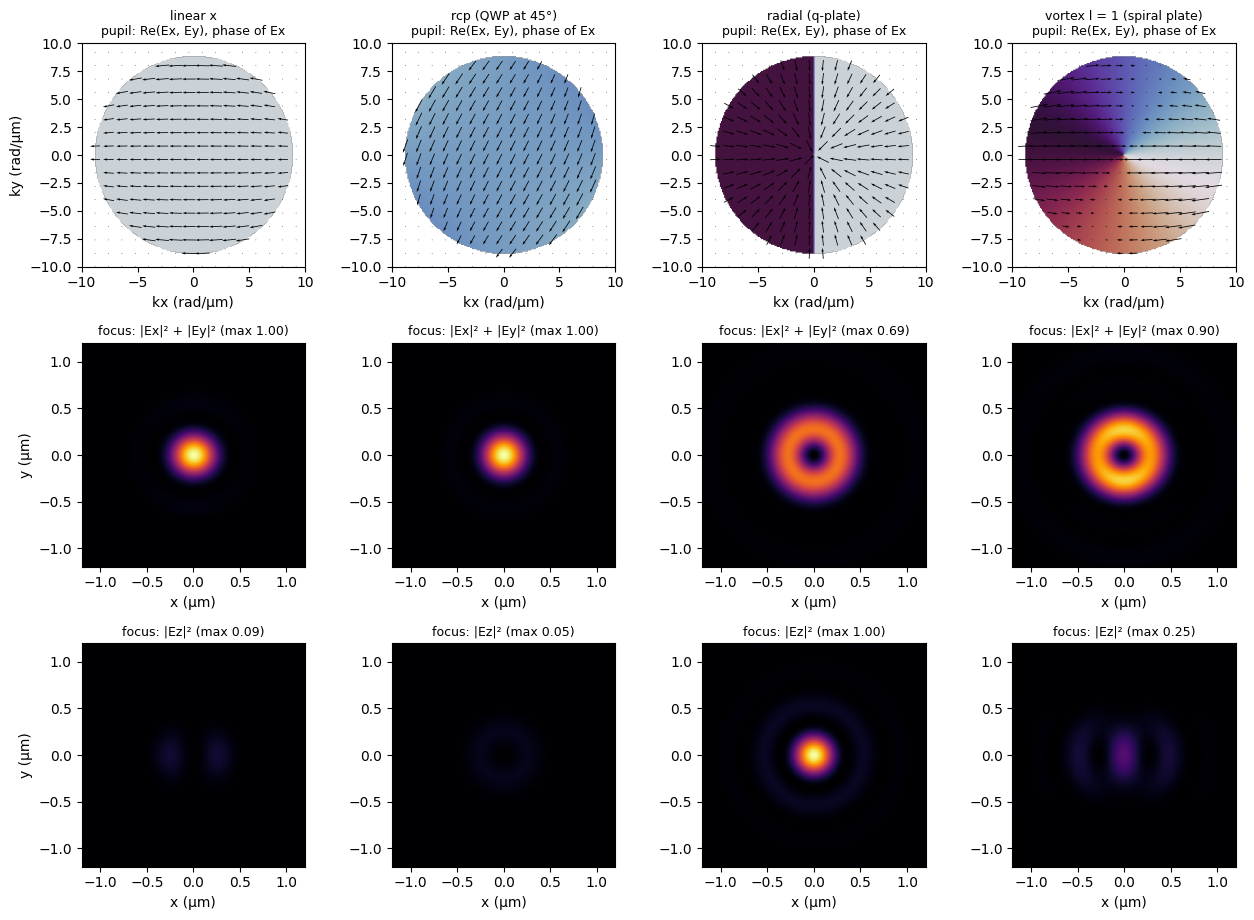

In [9]:
NA, wavelength = 0.75, 532e-9
objective = SWT.bls.ObjectiveLens(NA=NA, wavelength=wavelength, f0=10, f=1e-3)

# fine k-space grid covering the pupil (k0*NA = 8.9 rad/um) and a small real-space grid
k_f = np.linspace(-10e6, 10e6, 201)
KXf, KYf = np.meshgrid(k_f, k_f, indexing="ij")
x_f = np.linspace(-1.2e-6, 1.2e-6, 121)
F = np.exp(1j * np.outer(x_f, k_f)) * (k_f[1] - k_f[0])  # E(x) = sum_k E_k exp(i k x) dk


def focal_field(E_k):
    # focal field components on the grid x_f x x_f from the pupil field components
    return np.array([F @ E @ F.T for E in E_k])


beams = {
    "linear x": x_pol,
    "rcp (QWP at 45°)": pol.apply_jones_matrix(pol.quarter_wave_plate(45), x_pol),
    "radial (q-plate)": pol.apply_jones_matrix(pol.q_plate(KXf, KYf), x_pol),
    "vortex l = 1 (spiral plate)":
    pol.apply_jones_matrix(pol.spiral_phase_plate(KXf, KYf, charge=1), x_pol),
}

fig, axs = plt.subplots(3, len(beams), figsize=(3.2 * len(beams), 9.3))
ext_k = np.array([k_f[0], k_f[-1]] * 2) * 1e-6
ext_r = np.array([x_f[0], x_f[-1]] * 2) * 1e6
s = slice(None, None, 12)  # subsampling of the arrows
for col, (name, jones) in enumerate(beams.items()):
    E_k = np.array(objective.getPupilField(0, KXf, KYf, pol_type=jones))
    E_r = focal_field(E_k)
    I_t = np.abs(E_r[0])**2 + np.abs(E_r[1])**2
    I_z = np.abs(E_r[2])**2
    norm = (I_t + I_z).max()
    # pupil: phase of the dominant transverse component and the Re(E) direction
    ax = axs[0, col]
    amp = np.abs(E_k[:2]).max(axis=0)
    c_dom = np.argmax(np.abs(E_k[:2]).sum(axis=(1, 2)))
    phase = np.where(amp > 1e-3 * amp.max(), np.angle(E_k[c_dom]), np.nan)
    ax.imshow(phase.T, origin="lower", extent=ext_k, cmap="twilight",
              vmin=-np.pi, vmax=np.pi)
    ax.quiver(KXf[s, s] * 1e-6, KYf[s, s] * 1e-6, E_k[0][s, s].real,
              E_k[1][s, s].real, pivot="mid", scale=None, color="k")
    ax.set_title(f"{name}\npupil: Re(Ex, Ey), phase of E{'xy'[c_dom]}", fontsize=9)
    ax.set_xlabel("kx (rad/µm)")
    for row, (I, lab) in enumerate(((I_t, "|Ex|² + |Ey|²"),
                                    (I_z, "|Ez|²")), start=1):
        ax = axs[row, col]
        ax.imshow(I.T / norm, origin="lower", extent=ext_r, cmap="inferno",
                  vmin=0, vmax=1)
        ax.set_title(f"focus: {lab} (max {I.max() / norm:.2f})", fontsize=9)
        ax.set_xlabel("x (µm)")
axs[0, 0].set_ylabel("ky (rad/µm)")
axs[1, 0].set_ylabel("y (µm)")
axs[2, 0].set_ylabel("y (µm)")
plt.tight_layout()
plt.show()

### 3. Polarization-resolved BLS

Finally, we sweep the angle of the linear polarizer of the incident beam (α) and of the linear output analyzer (β) from 0° to 180° and calculate the BLS signal of a single magnon with `get_signal_GF_pupil()`.  The magnon has the wavevector (6, 0) rad/µm in a 30 nm thick NiFe layer magnetized along *y* by 50 mT (Damon-Eshbach geometry, mode n = 0 at about 10.5 GHz) with circular precession, i.e. the susceptibility is nonzero only at this point of the k-space grid.  Since the signal maps are normalized, the amplitude of the magnetization dynamics is arbitrary.

Two susceptibilities are compared: the linear magneto-optical effect alone (`mo_linear()`, Q = 1), and together with the quadratic one (`mo_quadratic()` linearized for the magnetization along *y*, B = 1).

magnon: k = (6.0, 0) rad/µm, f = 10.50 GHz


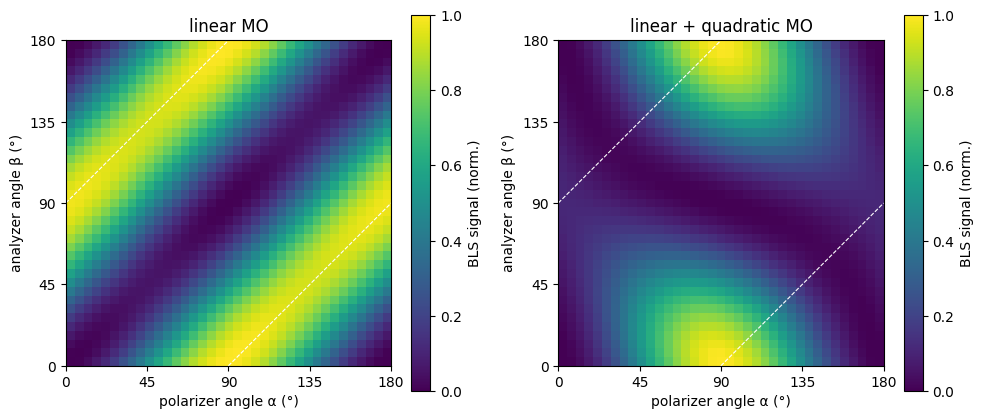

In [10]:
# k-space grid of the susceptibility and of the pupil fields
Nk, k_max = 61, 18e6
kx = ky = np.linspace(-k_max, k_max, Nk)
KX, KY = np.meshgrid(kx, ky, indexing="ij")
ix, iy = np.argmin(np.abs(kx - 6e6)), Nk // 2  # magnon wavevector (6, 0) rad/um

model = SWT.SingleLayer(Bext=50e-3, kxi=np.array([kx[ix]]), theta=np.pi / 2,
                        phi=np.pi / 2, d=30e-9, material=SWT.NiFe)
print(f"magnon: k = ({kx[ix] * 1e-6:.1f}, 0) rad/µm, "
      + f"f = {model.GetDispersion(n=0)[0] / 2e9 / np.pi:.2f} GHz")

# dynamic magnetization (M || y, circular precession) at the single wavevector
# and frequency -> simplification of a coherently excited magnon at given f(k)
m = np.zeros((3, 1, Nk, Nk), dtype=complex)
m[0, 0, ix, iy], m[2, 0, ix, iy] = 1, -1j
sus = SWT.bls.susceptibilities
chis = {
    "linear MO": sus.mo_linear(list(m), Q=1),
    "linear + quadratic MO": sus.mo_linear(list(m), Q=1)
    + sus.mo_quadratic(list(m), Bii=1, Bij=1, linearize_along="y"),
}
gf_params = dict(
    DF=[1, -8.1653 + 1j*15.348, 17.237 + 1j*0.43004],  # air, NiFe, substrate
    PM=[1, 1, 1], d=[30e-9], NA=NA, wavelength=wavelength,
    collectionSpot=0.5e-6, focalLength=1e-3, coherent_exc=True,
)

angles = np.arange(0, 181, 5)  # (deg) polarizer and analyzer angles


def polarization_map(chi):
    """BLS signal for all combinations of the polarizer (alpha) and
    analyzer (beta) angles.
    """
    sigma = np.zeros((len(angles), len(angles)))
    for i, alpha in enumerate(angles):
        Ei = objective.getPupilField(0, KX, KY, pol_type="linear",
                                     pol_angle=alpha)
        for j, beta in enumerate(angles):
            sigma[i, j] = SWT.bls.get_signal_GF_pupil(
                [kx, ky], Ei, chi, output_analyzer="linear",
                output_analyzer_angle_deg=beta, **gf_params)[0]
    return sigma


maps = {name: polarization_map(chi) for name, chi in chis.items()}

fig, axs = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, (name, sigma) in zip(axs, maps.items()):
    im = ax.imshow(sigma.T / sigma.max(), origin="lower",
                   extent=(0, 180, 0, 180), cmap="viridis")
    for off in (90, -90):  # crossed polarizations
        ax.plot(angles, angles + off, "w--", lw=0.8)
    ax.set_xlim(0, 180)
    ax.set_ylim(0, 180)
    ax.set_xticks(range(0, 181, 45))
    ax.set_yticks(range(0, 181, 45))
    ax.set_xlabel("polarizer angle α (°)")
    ax.set_ylabel("analyzer angle β (°)")
    ax.set_title(name)
    fig.colorbar(im, ax=ax, label="BLS signal (norm.)")
plt.tight_layout()
plt.show()

With the linear magneto-optical effect only, the polar Kerr effect of `mz` rotates the polarization of the scattered light by 90°, so the signal depends only on the difference of the angles, ∝ sin²(β − α), and is maximal for crossed polarizations (dashed lines), regardless of the orientation of the polarizer.  The quadratic effect of `mx` (components `χ_xy = χ_yx`) mirrors the polarization with respect to the diagonal *x* = *y*, which gives a signal ∝ sin²(α + β).  Both contributions interfere, so the map is no longer invariant along the diagonal: for crossed polarizations, the signal is maximal for the incident polarization along the magnetization (α = 90°) and almost vanishes for the perpendicular one (α = 0°), where the two contributions cancel for Q = B = 1.  The relative strength and phase of the two effects are set by the magneto-optical constants `Q` and `B` of the material, which can therefore be determined from such polarization-resolved measurements.

### 4. Polarization-resolved BLS with the reciprocity theorem

The same sweep can be calculated with the reciprocity theorem, here with `get_signal_RT_pupil()`.  Instead of the output analyzer, the detection is described by the virtual field `Ej`, i.e. the field that the detection path would focus onto the sample, so its polarization is the polarization transmitted by the analyzer.  Both `Ei` and `Ej` are therefore pupil fields linearly polarized at the angles α and β, respectively, which are calculated once for all angles.

The reciprocity theorem does not describe the propagation of light in the multilayer (the fields are those focused in the medium of the objective), whereas the Green function approach accounts for the reflection and transmission at the interfaces of the layer stack, which affect the in-plane and out-of-plane field components differently.  The maps are therefore similar, but not identical.

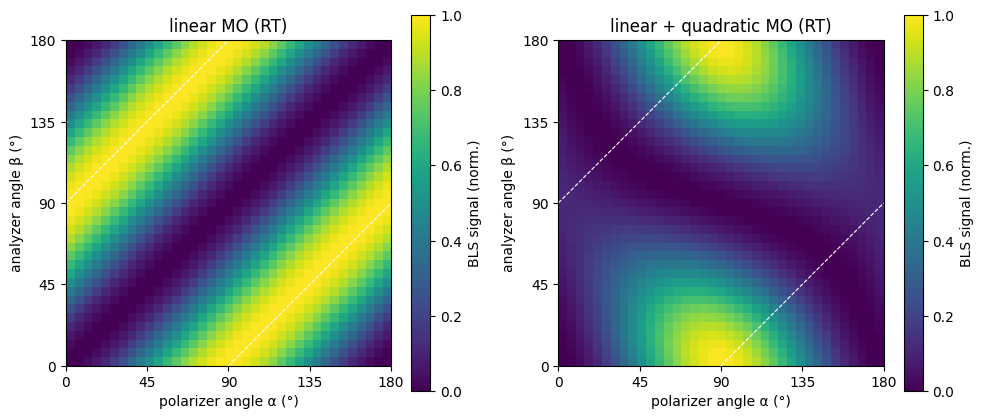

linear MO: max. difference of the normalized RT and GF maps 0.064
linear + quadratic MO: max. difference of the normalized RT and GF maps 0.020


In [ ]:
# pupil fields linearly polarized at all angles (used as Ei and Ej)
E_pol = {a: objective.getPupilField(0, KX, KY, pol_type="linear", pol_angle=a)
         for a in angles}


def polarization_map_RT(chi):
    """BLS signal (reciprocity theorem) for all combinations of the
    polarizer (alpha) and analyzer (beta) angles.
    """
    sigma = np.zeros((len(angles), len(angles)))
    for i, alpha in enumerate(angles):
        for j, beta in enumerate(angles):
            sigma[i, j] = SWT.bls.get_signal_RT_pupil(
                [kx, ky], E_pol[alpha], E_pol[beta], chi, coherent_exc=True)[0][0]
    return sigma


maps_RT = {name: polarization_map_RT(chi) for name, chi in chis.items()}

fig, axs = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, (name, sigma) in zip(axs, maps_RT.items()):
    im = ax.imshow(sigma.T / sigma.max(), origin="lower",
                   extent=(0, 180, 0, 180), cmap="viridis")
    for off in (90, -90):  # crossed polarizations
        ax.plot(angles, angles + off, "w--", lw=0.8)
    ax.set_xlim(0, 180)
    ax.set_ylim(0, 180)
    ax.set_xticks(range(0, 181, 45))
    ax.set_yticks(range(0, 181, 45))
    ax.set_xlabel("polarizer angle α (°)")
    ax.set_ylabel("analyzer angle β (°)")
    ax.set_title(f"{name} (RT)")
    fig.colorbar(im, ax=ax, label="BLS signal (norm.)")
plt.tight_layout()
plt.show()

for name in chis:
    gf, rt = maps[name] / maps[name].max(), maps_RT[name] / maps_RT[name].max()
    print(f"{name}: max. difference of the normalized RT and GF maps {np.abs(rt - gf).max():.3f}")